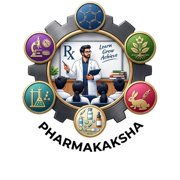

# BP201T · Unit I — Descriptive Statistics
**Pharmakaksha · Learn · Grow · Achieve**
*Applied Biostatistics and Data Analytics for Pharmaceutical Sciences · B.Pharm Semester II · PCI NEP 2020*

This notebook contains every example and demo from the Unit I study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP201T%20Applied%20Biostatistics%20and%20Data%20Analytics%20for%20Pharmaceutical%20Sciences%20%28Theory%29/BP201T_Unit1_Descriptive_Statistics.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP201T%20Applied%20Biostatistics%20and%20Data%20Analytics%20for%20Pharmaceutical%20Sciences%20%28Theory%29/BP201T_Unit1_Descriptive_Statistics.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import scipy` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data. The analyses are for learning statistics only. They are not clinical or regulatory decisions.

## 1.1 Why statistics, and where pharmacy data come from
Every decision in pharmacy rests on data: is a batch within limits, does a drug lower blood pressure, is an adverse reaction more common than expected? **Biostatistics** is the toolkit for collecting, summarising and interpreting those data.

| Source | What it records | Example question |
|---|---|---|
| Clinical trials | Outcomes of patients on drug vs placebo | Does the drug lower SBP more than placebo? |
| Pharmacovigilance (PV) | Adverse drug reaction (ADR) reports | Are ADR reports rising this month? |
| Quality control (QC) | Weights, assay, dissolution of batches | Is this batch within IP limits? |
| PK studies | Drug concentrations over time | What is the typical AUC, and how variable is it? |

This cell loads the libraries and a helper that reads the practice datasets.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP201T%20Applied%20Biostatistics%20and%20Data%20Analytics%20for%20Pharmaceutical%20Sciences%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

## 1.2 Types of data
Our main dataset, `bp_trial.csv`, is a fictional 8-week trial of an antihypertensive in 120 patients (60 on the drug, 60 on placebo).

In [ ]:
bp = load("bp_trial.csv")
print(bp.shape)
bp.head()

| Scale | Meaning | Order? | Equal steps? | True zero? | Columns in `bp_trial.csv` |
|---|---|---|---|---|---|
| **Nominal** | Named categories | No | No | No | `group`, `sex`, `smoker`, `adr` |
| **Ordinal** | Ordered categories | Yes | No | No | `severity` (Mild < Moderate < Severe) |
| **Interval** | Numbers with equal steps, zero is arbitrary | Yes | Yes | No | `temp_c` (0 °C is not "no temperature") |
| **Ratio** | Numbers with a true zero | Yes | Yes | Yes | `age`, `bmi`, `baseline_sbp`, `week8_sbp` |

Nominal and ordinal data are **qualitative (categorical)**; interval and ratio data are **quantitative (numerical)**. Pandas stores text categories as `object` (or `str`) and numbers as `int64` or `float64`.

In [ ]:
print(bp.dtypes)

# Tell pandas that severity has an order
bp["severity"] = pd.Categorical(bp["severity"], categories=["Mild", "Moderate", "Severe"], ordered=True)
print(bp["severity"].value_counts().sort_index())

## 1.3 Measures of central tendency: mean, median, mode
`tablet_weights.csv` holds the weights of 20 tablets from each of two batches of a 250 mg tablet.

In [ ]:
tw = load("tablet_weights.csv")
a = tw[tw["batch"] == "A"]["weight_mg"]
b = tw[tw["batch"] == "B"]["weight_mg"]
print(a.values)

# Mean by the formula: sum of values / number of values
print("Mean (by hand):", round(sum(a) / len(a), 2))
print("Mean (NumPy):  ", round(np.mean(a), 2))
print("Median:        ", np.median(a))

The **median** is the middle value after sorting, so one extreme value barely moves it. In the PK study (`pk_volunteers.csv`, 40 volunteers) a few people had a very high AUC. Compare the mean and the median.

In [ ]:
pk = load("pk_volunteers.csv")
auc = pk["auc_ng_h_ml"]
print("Mean AUC:  ", round(auc.mean(), 1))
print("Median AUC:", auc.median())

# The mode is the most frequent value: useful for discrete and categorical data
print("Mode of Tmax (h):", pk["tmax_h"].mode()[0])
print("Mode of severity:", bp["severity"].mode()[0])

## 1.4 Measures of dispersion: range, variance, standard deviation
Both batches have a similar average weight, but are they equally **consistent**?

In [ ]:
for name, w in [("A", a), ("B", b)]:
    print(f"Batch {name}: mean {w.mean():.2f}  range {w.max() - w.min():.1f}  "
          f"variance {w.var():.2f}  SD {w.std():.2f}  CV {100 * w.std() / w.mean():.2f}%")

**Sample variance** is $s^2 = \frac{\sum (x - \bar{x})^2}{n - 1}$ and the **standard deviation** is its square root, in the same units as the data (mg). The **coefficient of variation** (CV, or %RSD) = SD / mean × 100.

> **Watch out:** pandas `.std()` divides by *n − 1* (sample SD), but NumPy `np.std()` divides by *n* unless you write `ddof=1`.

In [ ]:
print("pandas .std():        ", round(a.std(), 3))
print("np.std(a):            ", round(np.std(a), 3))
print("np.std(a, ddof=1):    ", round(np.std(a, ddof=1), 3))

# Variance step by step
dev = a - a.mean()
print("Sum of squared deviations:", round((dev ** 2).sum(), 2))
print("Variance = SS / (n - 1):  ", round((dev ** 2).sum() / (len(a) - 1), 3))

In [ ]:
plt.figure(figsize=(8, 4.5))
plt.boxplot([a, b], widths=0.5,
            patch_artist=True, boxprops=dict(facecolor="#DFF3EC", color="#12303A"),
            medianprops=dict(color="#E07A2E", linewidth=2))
plt.xticks([1, 2], ["Batch A", "Batch B"])
plt.axhspan(237.5, 262.5, color="#17725C", alpha=0.08, label="IP limit 250 mg ± 5%")
plt.axhline(250, color="#17725C", linestyle=":", linewidth=1)
plt.ylabel("Tablet weight (mg)")
plt.title("Same target, different consistency")
plt.legend(loc="lower left"); plt.grid(axis="y", alpha=0.3); plt.show()

## 1.5 Skewness
A distribution is **symmetric** when the left and right sides mirror each other (mean ≈ median). It is **positively (right) skewed** when a long tail stretches to the right (mean > median), and **negatively (left) skewed** when the tail stretches to the left (mean < median). PK exposures such as AUC are usually right-skewed.

In [ ]:
print("Skewness of AUC:          ", round(auc.skew(), 2))
print("Skewness of batch A weight:", round(a.skew(), 2))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].hist(a, bins=8, color="#1F8A70", edgecolor="white")
ax[0].axvline(a.mean(), color="#E07A2E", linewidth=2, label=f"Mean {a.mean():.1f}")
ax[0].axvline(a.median(), color="#12303A", linestyle="--", linewidth=2, label=f"Median {a.median():.1f}")
ax[0].set_title("Batch A weights: roughly symmetric"); ax[0].set_xlabel("Weight (mg)"); ax[0].legend()
ax[1].hist(auc, bins=10, color="#1F8A70", edgecolor="white")
ax[1].axvline(auc.mean(), color="#E07A2E", linewidth=2, label=f"Mean {auc.mean():.0f}")
ax[1].axvline(auc.median(), color="#12303A", linestyle="--", linewidth=2, label=f"Median {auc.median():.0f}")
ax[1].set_title("AUC: right (positively) skewed"); ax[1].set_xlabel("AUC (ng·h/mL)"); ax[1].legend()
for x in ax: x.set_ylabel("Number of values")
plt.tight_layout(); plt.show()

## 1.6 Descriptive statistics with NumPy and Pandas
`describe()` gives the count, mean, SD, minimum, quartiles and maximum of every numeric column in one line.

In [ ]:
bp[["age", "bmi", "baseline_sbp", "week8_sbp", "sbp_drop"]].describe().round(1)

For a trial we summarise each **group** separately. `groupby` + `agg` builds the classic "Table 1".

In [ ]:
summary = bp.groupby("group")[["age", "baseline_sbp", "sbp_drop"]].agg(["mean", "std"]).round(1)
summary

Categorical columns are summarised with **counts and percentages**, not means.

In [ ]:
print(bp["sex"].value_counts())
print((bp["sex"].value_counts(normalize=True) * 100).round(1))
pd.crosstab(bp["group"], bp["adr"], margins=True)

## Worked example: a QC summary for both batches
A QC analyst reports the mean, SD, %RSD and how many tablets fall outside the IP limit of **250 mg ± 5% (237.5–262.5 mg)**. The IP test passes if no more than 2 of 20 tablets deviate by more than 5% and none deviates by more than 10%.

In [ ]:
def qc_summary(w, label=250, limit_pct=5):
    lo, hi = label * (1 - limit_pct / 100), label * (1 + limit_pct / 100)
    outside = ((w < lo) | (w > hi)).sum()
    outside_double = ((w < label * 0.9) | (w > label * 1.1)).sum()
    return pd.Series({"n": len(w), "mean": round(w.mean(), 2), "SD": round(w.std(), 2),
                      "%RSD": round(100 * w.std() / w.mean(), 2), "min": w.min(), "max": w.max(),
                      "outside ±5%": outside, "outside ±10%": outside_double,
                      "IP result": "Pass" if outside <= 2 and outside_double == 0 else "Fail"})

pd.DataFrame({"Batch A": qc_summary(a), "Batch B": qc_summary(b)})

## Quick check
A dataset of hospital stay (days) has mean 6.2 and median 4. Which way is it skewed? Decide, then run the cell.

In [ ]:
print("Mean > median, so the long tail is on the right: positively (right) skewed.")

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** Classify each column of `pk_volunteers.csv` as nominal, ordinal, interval or ratio.

**2.** Find the mean, median, SD and CV of `cmax_ng_ml`. Is it skewed?

**3.** Using `bp_trial.csv`, find the mean `sbp_drop` for each `severity` level.

**4.** Make a histogram of `baseline_sbp` and mark its mean and median.

---
## Solutions

In [ ]:
# 1
# volunteer_id: nominal (a label); weight_kg, tmax_h, cmax_ng_ml, auc_ng_h_ml: ratio (true zero)
print(load("pk_volunteers.csv").dtypes)

In [ ]:
# 2
c = load("pk_volunteers.csv")["cmax_ng_ml"]
print(round(c.mean(), 1), c.median(), round(c.std(), 1), round(100 * c.std() / c.mean(), 1), "%")
print("Skewness:", round(c.skew(), 2))   # positive: mean > median, right-skewed

In [ ]:
# 3
bp = load("bp_trial.csv")
bp.groupby("severity")["sbp_drop"].mean().round(1)

In [ ]:
# 4
s = load("bp_trial.csv")["baseline_sbp"]
plt.hist(s, bins=12, color="#1F8A70", edgecolor="white")
plt.axvline(s.mean(), color="#E07A2E", label="Mean")
plt.axvline(s.median(), color="#12303A", linestyle="--", label="Median")
plt.xlabel("Baseline SBP (mmHg)"); plt.legend(); plt.show()

---
**Next:** Unit II — Probability and Distributions in Healthcare. Pharmakaksha · Learn · Grow · Achieve